**Resource:** _"[The Matrix Calculus You Need for Deep Learning](https://arxiv.org/abs/1802.01528)"_ Parr & Howard

The introduction says _"We’re assuming you’re already familiar with the basics of neural network architecture and training"_ and I do, but heads-up in case you're following along.

In this notebook, I'll summarize what I consider relevant and implement in the next one.

#### ds/ds Derivative of a Scalar wrt another Scalar

I'm already familiar with scalar calculus and partial derivatives

#### ds/dv Derivative of a Scalar wrt a Vector

Let $y = f(x_1, x_2)$

we can take partial derivatives $\frac{\partial y}{\partial x_1}$ and $\frac{\partial y}{\partial x_2}$

If we couple $x_1$ and $x_2$ as the vector $\textbf{x} = \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}$, then $\frac{\partial y}{\partial\textbf{x}}$ is $\begin{bmatrix} \frac{\partial y}{\partial x_1} & \frac{\partial y}{\partial x_2} \end{bmatrix}$

This is also called the gradient of the function $f$

I'm using a row vector because that's the convention the book uses. Some other sources I've come across use column vectors instead.

#### dv/ds Derivative of a Vector wrt a Scalar

Let $y_1 = f_1(x)$ and $y_2 = f_2(x)$ be functions of $x$
we can take derivatives $\frac{dy_1}{dx}$ and $\frac{dy_1}{dx}$ (not partial in this case)

If we couple $y_1$ and $y_2$ as the vector $\textbf{y} = \begin{bmatrix} y_1 \\ y_2 \end{bmatrix}$, then $\frac{d\textbf{y}}{dx}$ is $\begin{bmatrix} \frac{dy_1}{dx} \\ \frac{dy_2}{dx} \end{bmatrix}$

#### dv/dv Derivative of a Vector wrt another Vector

Finally, if $\textbf{x}$ and $\textbf{y}$ are vectors and $\textbf{y} = \textbf{f}(\textbf{x})$, the derivative is a collection of all possible $\frac{\partial y_i}{\partial x_j}$ in a matrix called the _Jacobian_.

$\frac{\partial\textbf{y}}{\partial\textbf{x}}$ or $\nabla_\textbf{x}\textbf{y}$ $=J$ where $J_{ij} = \frac{\partial{y_i}}{\partial x_j}$

Once again, there are different conventions, but the book uses this.

#### Element-wise Operators

Say $\textbf{y} = f(\textbf{w}) \circ g(\textbf{x})$, a form I see a lot in neural networks.

A couple of simplifications we can make:
- $\circ$ (an operator like $+-\times /$, not composition) is element-wise i.e. $(a \circ b)_i = a_i \circ b_i$
- $f$ and $g$ are element-wise i.e. $f(x)_i = f(x_i)$

If these hold, then the derivatives are diagonal matrices

$\frac{\partial\textbf{y}}{\partial\textbf{w}} = \text{diag}(\frac{\partial{y_i}}{\partial w_i})$

$\frac{\partial\textbf{y}}{\partial\textbf{x}} = \text{diag}(\frac{\partial{y_i}}{\partial x_i})$

Here's that section from the textbook for reference:
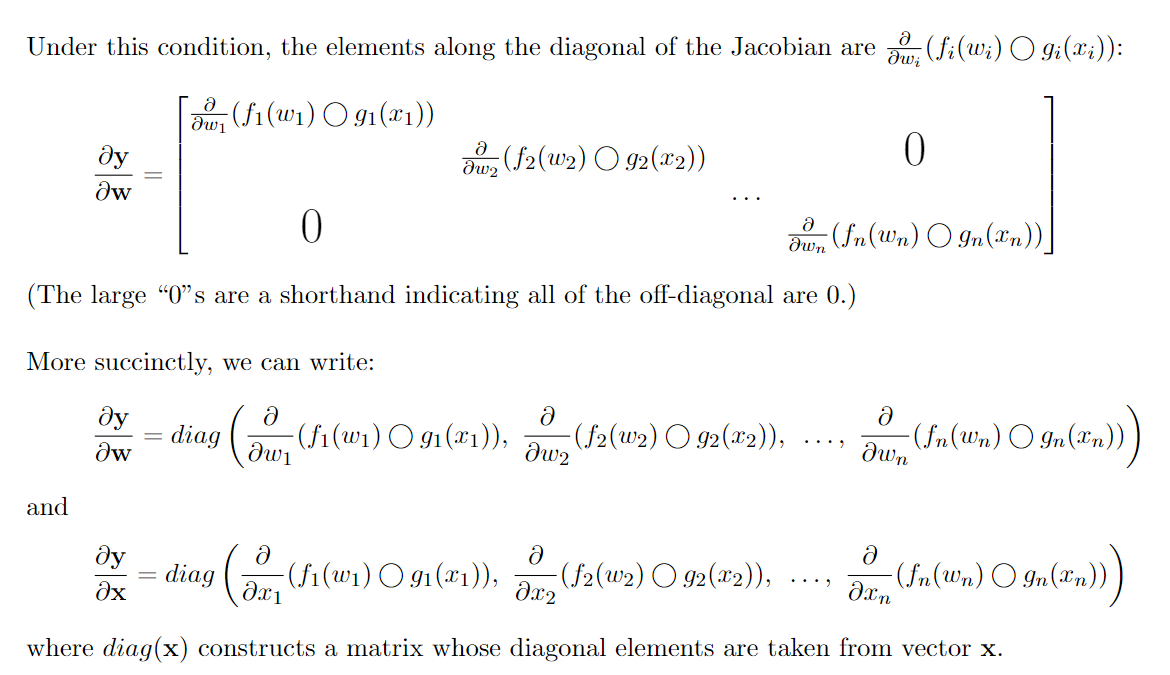

#### Relevant Element-wise Derivatives

$\textbf{y}$ | $\frac{\partial\textbf{y}}{\partial\textbf{w}}$ | $\frac{\partial\textbf{y}}{\partial\textbf{x}}$
---|---|---
$\textbf{w} + \textbf{x}$ | $I$ | $I$
$\textbf{w} - \textbf{x}$ | $I$ | $-I$
$\textbf{w} * \textbf{x}$ | $\text{diag}(\textbf{x})$ | $\text{diag}(\textbf{w})$
$\textbf{w} / \textbf{x}$ | $\text{diag}(1/\textbf{x})$ | $\text{diag}(-\textbf{w}/\textbf{x}^2)$

**Note:** $*$ for element-wise multiplication and $/$ for element-wise division

**PS:** in case one input is scalar, we can replace with a vector of the same size as x. Pytorch calls this _broadcasting_.

For example, if $\textbf{w}$ is a scalar, then $\textbf{y} = \textbf{w} + \textbf{x}$ is equivalent to $\begin{bmatrix} w \\ w \\ w \end{bmatrix} + \textbf{x}$

Then we proceed as usual, the only difference being that $\frac{\partial\textbf{y}}{\partial w}$ would be $\textbf{1}$ (a vector of ones) instead of a diagonal matrix.

I found this diagram really useful:

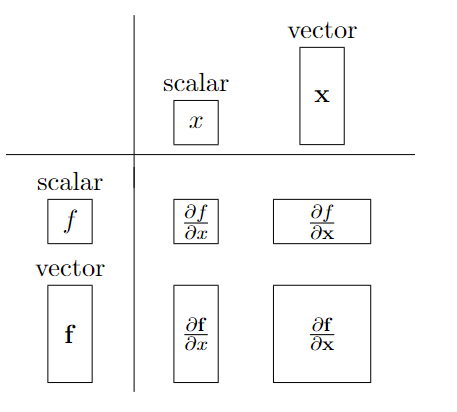

A special case is $y = \text{sum}(\textbf{x})$ where $y$ is of course a scalar.
Here, $\frac{\partial y}{\partial\textbf{x}} = \textbf{1}^T$ (a row vector of ones)

#### Chain Rule

To simplify things, I'll treat differentiation similar to how I did for scalar autodiff by introducing intermediate variables

For example, $\textbf{y} = \textbf{f}(\textbf{g}(\textbf{x}))$
- $\textbf{y} = \textbf{f}(\textbf{a})$
- $\textbf{a} = \textbf{g}(\textbf{x})$

Then $\frac{\partial\textbf{y}}{\partial\textbf{x}} = \frac{\partial\textbf{y}}{\partial\textbf{a}} \frac{\partial\textbf{a}}{\partial\textbf{x}}$

Each of those derivatives are matrices so the result is a matrix multiplication

For functions/operators with more than one inputs, for example, $\textbf{y} = \textbf{f}(\textbf{g}(\textbf{w}, \textbf{x}), \textbf{h}(\textbf{w}, \textbf{x}))$
- $\textbf{y} = \textbf{f}(\textbf{a},\textbf{b})$
- $\textbf{a} = \textbf{g}(\textbf{w},\textbf{x})$
- $\textbf{b} = \textbf{h}(\textbf{w},\textbf{x})$

Then:
- $\frac{\partial\textbf{y}}{\partial\textbf{w}} = \frac{\partial\textbf{y}}{\partial\textbf{a}} \frac{\partial\textbf{a}}{\partial\textbf{w}} + \frac{\partial\textbf{y}}{\partial\textbf{b}} \frac{\partial\textbf{b}}{\partial\textbf{w}}$
- $\frac{\partial\textbf{y}}{\partial\textbf{x}} = \frac{\partial\textbf{y}}{\partial\textbf{a}} \frac{\partial\textbf{a}}{\partial\textbf{x}} + \frac{\partial\textbf{y}}{\partial\textbf{b}} \frac{\partial\textbf{b}}{\partial\textbf{x}}$

I haven't read chapters 5 onwards yet, but I believe this is all I need to implement vectordiff. lfg